=== PRESCRIPTIVE ADVANCED OPTIMIZATION STATISTICS ===
Potential Revenue Growth: +$18,637.25 (+6.49%)
Potential Net Profit Growth: +$18,637.25 (+21.91%)

Prescriptive scenario chart 'prescriptive_discount_optimization.png' exported successfully!


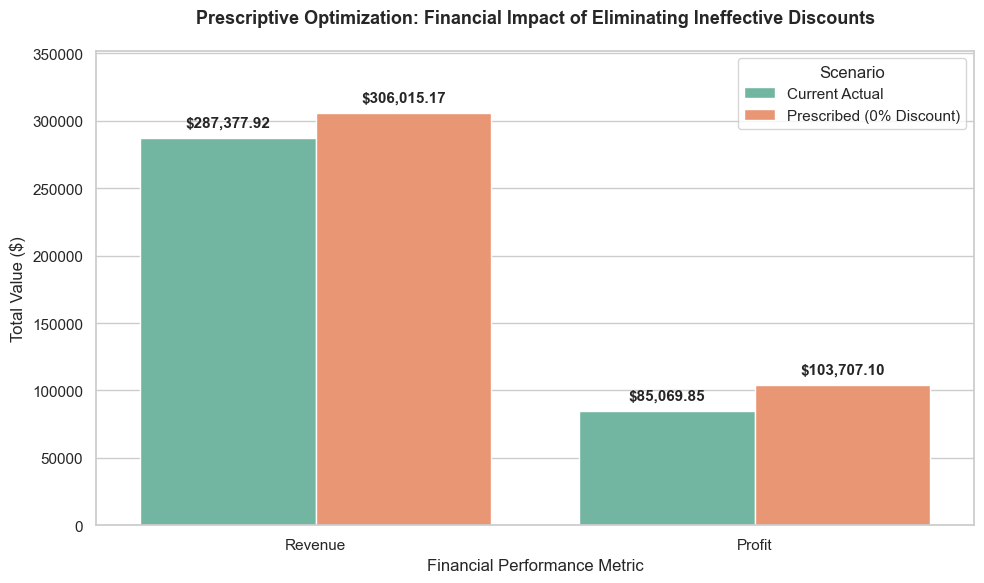

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# 1. Load Data & Isolate Structural Cost of Goods Sold
# -------------------------------------------------------------------------
df = pd.read_csv('C:/Users/Mindworx/Downloads/adidas_dataset.csv')

# Cost = Gross Revenue minus the generated Profit
df['Cost'] = df['Revenue'] - df['Profit']

# -------------------------------------------------------------------------
# 2. Simulate the Prescriptive Scenario (0% Strategic Discounts)
# -------------------------------------------------------------------------
# Formula: Revenue at full price without markdown erosion
df['Simulated_Revenue_No_Discount'] = df['Units_Sold'] * df['Unit_Price']

# Profit under optimized full-price strategy assuming baseline product cost remains static
df['Simulated_Profit_No_Discount'] = df['Simulated_Revenue_No_Discount'] - df['Cost']

# Aggregating Totals
actual_revenue = df['Revenue'].sum()
actual_profit = df['Profit'].sum()

simulated_revenue = df['Simulated_Revenue_No_Discount'].sum()
simulated_profit = df['Simulated_Profit_No_Discount'].sum()

rev_lift = simulated_revenue - actual_revenue
prof_lift = simulated_profit - actual_profit

print("=== PRESCRIPTIVE ADVANCED OPTIMIZATION STATISTICS ===")
print(f"Potential Revenue Growth: +${rev_lift:,.2f} (+{rev_lift/actual_revenue*100:.2f}%)")
print(f"Potential Net Profit Growth: +${prof_lift:,.2f} (+{prof_lift/actual_profit*100:.2f}%)\n")


# -------------------------------------------------------------------------
# 3. Generate Dashboard Comparison Visualization
# -------------------------------------------------------------------------
sns.set_theme(style="whitegrid")

# Restructure metrics into tidy format for seaborn plotting
comparison_df = pd.DataFrame({
    'Metric': ['Revenue', 'Revenue', 'Profit', 'Profit'],
    'Scenario': ['Current Actual', 'Prescribed (0% Discount)', 'Current Actual', 'Prescribed (0% Discount)'],
    'Amount ($)': [actual_revenue, simulated_revenue, actual_profit, simulated_profit]
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Metric', y='Amount ($)', hue='Scenario', palette='Set2', ax=ax)

# Place high-visibility value callout text above data bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'${height:,.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 6),
                    textcoords='offset points', fontsize=11, weight='bold')

ax.set_title('Prescriptive Optimization: Financial Impact of Eliminating Ineffective Discounts', fontsize=13, pad=20, weight='bold')
ax.set_ylabel('Total Value ($)', fontsize=12)
ax.set_xlabel('Financial Performance Metric', fontsize=12)
ax.set_ylim(0, max(simulated_revenue, simulated_profit) * 1.15)

plt.tight_layout()

print("Prescriptive scenario chart 'prescriptive_discount_optimization.png' exported successfully!")